# Bays (2014) Figure 1 d,e,f — GP-Based Equivalent

In [7]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time

from core.encoder.gaussian_process import (
    generate_neuron_population, periodic_rbf_kernel, sample_gp_function,
)
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


In [8]:
def compute_log_likelihood(counts, g, T_d):
    log_g = np.log(np.maximum(g, 1e-30))
    return counts @ log_g - T_d * np.sum(g, axis=0)

def compute_circular_error(theta_true, theta_hat):
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

def circular_variance(errors):
    return 1.0 - np.abs(np.mean(np.exp(1j * errors)))

def circular_kurtosis(errors):
    V = circular_variance(errors)
    rho2 = np.abs(np.mean(np.exp(2j * errors)))
    kappa2 = 1.0 - rho2
    return kappa2 / max(V**2, 1e-15) if V > 1e-10 else 0.0

In [9]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0, seed=seed)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

In [19]:
M = 100; N_THETA = 256; N_TRIALS = 2000; T_D = 0.1; SIGMA_SQ = 1e-6  

N_GRID = 12; LAMBDA_RANGE = (0.1, 2.5); GAMMA_RANGE = (1.0, 256.0); SEED = 42
lambdas = np.logspace(np.log2(LAMBDA_RANGE[0]), np.log2(LAMBDA_RANGE[1]), N_GRID, base=2)
gammas = np.logspace(np.log2(GAMMA_RANGE[0]), np.log2(GAMMA_RANGE[1]), N_GRID, base=2)
print(f"Grid: {N_GRID}x{N_GRID}, {N_TRIALS} trials each")

Grid: 12x12, 2000 trials each


In [20]:
t0 = time.time()
variance_grid = np.full((N_GRID, N_GRID), np.nan)
kurtosis_grid = np.full((N_GRID, N_GRID), np.nan)
variance_half = np.full((N_GRID, N_GRID), np.nan)

for i, lam in enumerate(lambdas):
    thetas, f_all = generate_population(M, N_THETA, lam, n_locations=1, seed=SEED + i*1000)
    g = np.exp(f_all[0])
    for j, gam in enumerate(gammas):
        rng = np.random.RandomState(SEED + i*N_GRID + j)
        errors = np.empty(N_TRIALS)
        for t in range(N_TRIALS):
            idx = rng.randint(N_THETA)
            rates = dn_pointwise(g[:, idx], gam, SIGMA_SQ)
            counts = generate_spikes(rates, T_D, rng)
            ll = compute_log_likelihood(counts, g, T_D)
            errors[t] = compute_circular_error(thetas[idx], thetas[np.argmax(ll)])
        variance_grid[j, i] = circular_variance(errors)
        kurtosis_grid[j, i] = circular_kurtosis(errors)

        rng2 = np.random.RandomState(SEED + i*N_GRID + j + N_GRID**2)
        eh = np.empty(N_TRIALS)
        for t in range(N_TRIALS):
            idx = rng2.randint(N_THETA)
            rates = dn_pointwise(g[:, idx], gam/2, SIGMA_SQ)
            counts = generate_spikes(rates, T_D, rng2)
            ll = compute_log_likelihood(counts, g, T_D)
            eh[t] = compute_circular_error(thetas[idx], thetas[np.argmax(ll)])
        variance_half[j, i] = circular_variance(eh)
    print(f"  lam={lam:.3f} done ({(i+1)/N_GRID*100:.0f}%, {time.time()-t0:.0f}s)")

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(variance_half > 1e-15, variance_grid / variance_half, np.nan)
    exponent_grid = np.where(ratio > 0, np.log2(ratio), np.nan)
print(f"Done in {time.time()-t0:.1f}s")

  lam=0.100 done (8%, 13s)
  lam=0.134 done (17%, 21s)
  lam=0.180 done (25%, 28s)
  lam=0.241 done (33%, 35s)
  lam=0.322 done (42%, 43s)
  lam=0.432 done (50%, 51s)
  lam=0.579 done (58%, 61s)
  lam=0.776 done (67%, 71s)
  lam=1.039 done (75%, 80s)
  lam=1.392 done (83%, 91s)
  lam=1.866 done (92%, 101s)
  lam=2.500 done (100%, 113s)
Done in 113.5s


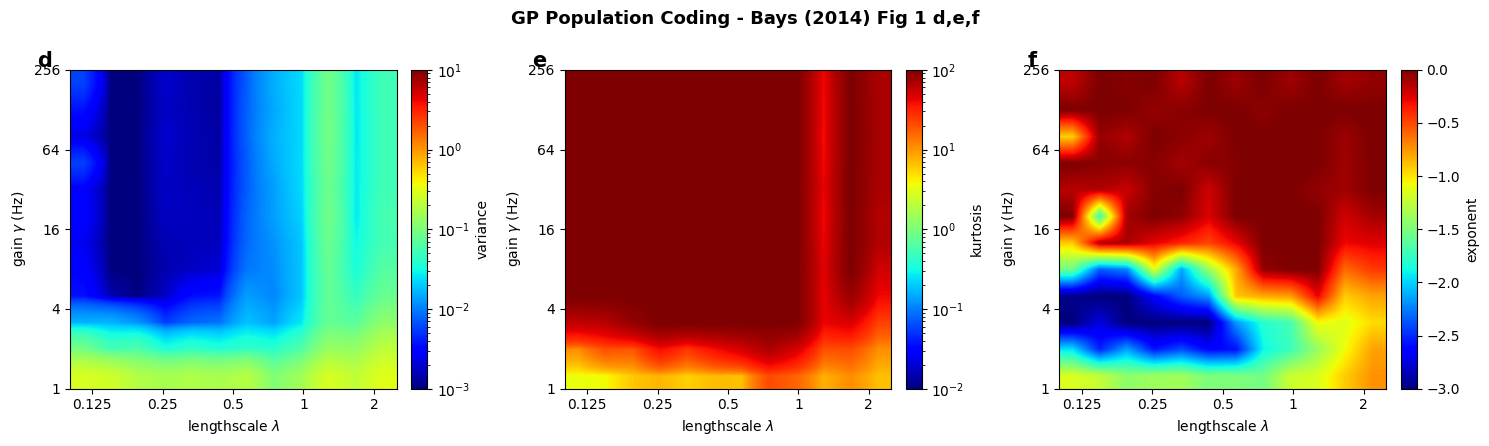

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ext = [np.log2(lambdas[0]), np.log2(lambdas[-1]), np.log2(gammas[0]), np.log2(gammas[-1])]
def fmt_ax(ax, label):
    ax.set_xlabel(r'lengthscale $\lambda$'); ax.set_ylabel(r'gain $\gamma$ (Hz)')
    xt = np.array([0.125,0.25,0.5,1,2]); xt = xt[(xt>=lambdas[0]*0.9)&(xt<=lambdas[-1]*1.1)]
    ax.set_xticks(np.log2(xt)); ax.set_xticklabels([f'{v:g}' for v in xt])
    yt = np.array([1,4,16,64,256]); yt = yt[(yt>=gammas[0]*0.9)&(yt<=gammas[-1]*1.1)]
    ax.set_yticks(np.log2(yt)); ax.set_yticklabels([f'{v:g}' for v in yt])
    ax.text(-0.1,1.06,f'$\mathbf{{{label}}}$',transform=ax.transAxes,fontsize=15,fontweight='bold',va='top')
im0 = axes[0].imshow(np.clip(variance_grid,1e-3,10),origin='lower',aspect='auto',extent=ext,norm=mcolors.LogNorm(vmin=0.001,vmax=10),cmap='jet',interpolation='bilinear')
fig.colorbar(im0,ax=axes[0],fraction=0.046,pad=0.04).set_label('variance'); fmt_ax(axes[0],'d')
im1 = axes[1].imshow(np.clip(kurtosis_grid,0.01,100),origin='lower',aspect='auto',extent=ext,norm=mcolors.LogNorm(vmin=0.01,vmax=100),cmap='jet',interpolation='bilinear')
fig.colorbar(im1,ax=axes[1],fraction=0.046,pad=0.04).set_label('kurtosis'); fmt_ax(axes[1],'e')
im2 = axes[2].imshow(np.clip(exponent_grid,-3,0),origin='lower',aspect='auto',extent=ext,vmin=-3,vmax=0,cmap='jet',interpolation='bilinear')
fig.colorbar(im2,ax=axes[2],fraction=0.046,pad=0.04).set_label('exponent'); fmt_ax(axes[2],'f')
fig.suptitle('GP Population Coding - Bays (2014) Fig 1 d,e,f',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()